In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Configuración de aleatoriedad para reproducibilidad
np.random.seed(42)

# 1. Generación de datos simulados (1000 usuarios)
n_rows = 1000
planes = ['Básico', 'Estándar', 'Premium']

# Generamos planes aleatorios
user_plans = np.random.choice(planes, n_rows, p=[0.4, 0.35, 0.25])

# Generamos el estado de cancelación con probabilidades dependientes del plan
# El plan Básico tendrá mayor tasa de cancelación (Churn)
churn_status = []
for plan in user_plans:
    if plan == 'Básico':
        status = np.random.choice(['Activo', 'Cancelado'], p=[0.6, 0.4])
    elif plan == 'Estándar':
        status = np.random.choice(['Activo', 'Cancelado'], p=[0.75, 0.25])
    else: # Premium
        status = np.random.choice(['Activo', 'Cancelado'], p=[0.85, 0.15])
    churn_status.append(status)

# Crear DataFrame
df = pd.DataFrame({
    'ID_Usuario': range(1, n_rows + 1),
    'Plan': user_plans,
    'Estado': churn_status,
    'Region': np.random.choice(['Norte', 'Sur', 'Centro'], n_rows)
})

print("Dataset generado con éxito. Primeras filas:")
print(df.head())
df.to_csv("sp9_3.csv")

Dataset generado con éxito. Primeras filas:
   ID_Usuario      Plan     Estado  Region
0           1    Básico     Activo  Centro
1           2   Premium     Activo  Centro
2           3  Estándar  Cancelado  Centro
3           4  Estándar     Activo     Sur
4           5    Básico  Cancelado     Sur


In [31]:
# Tabla de frecuencias cruzadas
tabla_contingencia = pd.crosstab(df['Plan'], df['Estado'])
print("\nTabla de Contingencia:")
print(tabla_contingencia)


Tabla de Contingencia:
Estado    Activo  Cancelado
Plan                       
Básico       240        181
Estándar     258         78
Premium      209         34


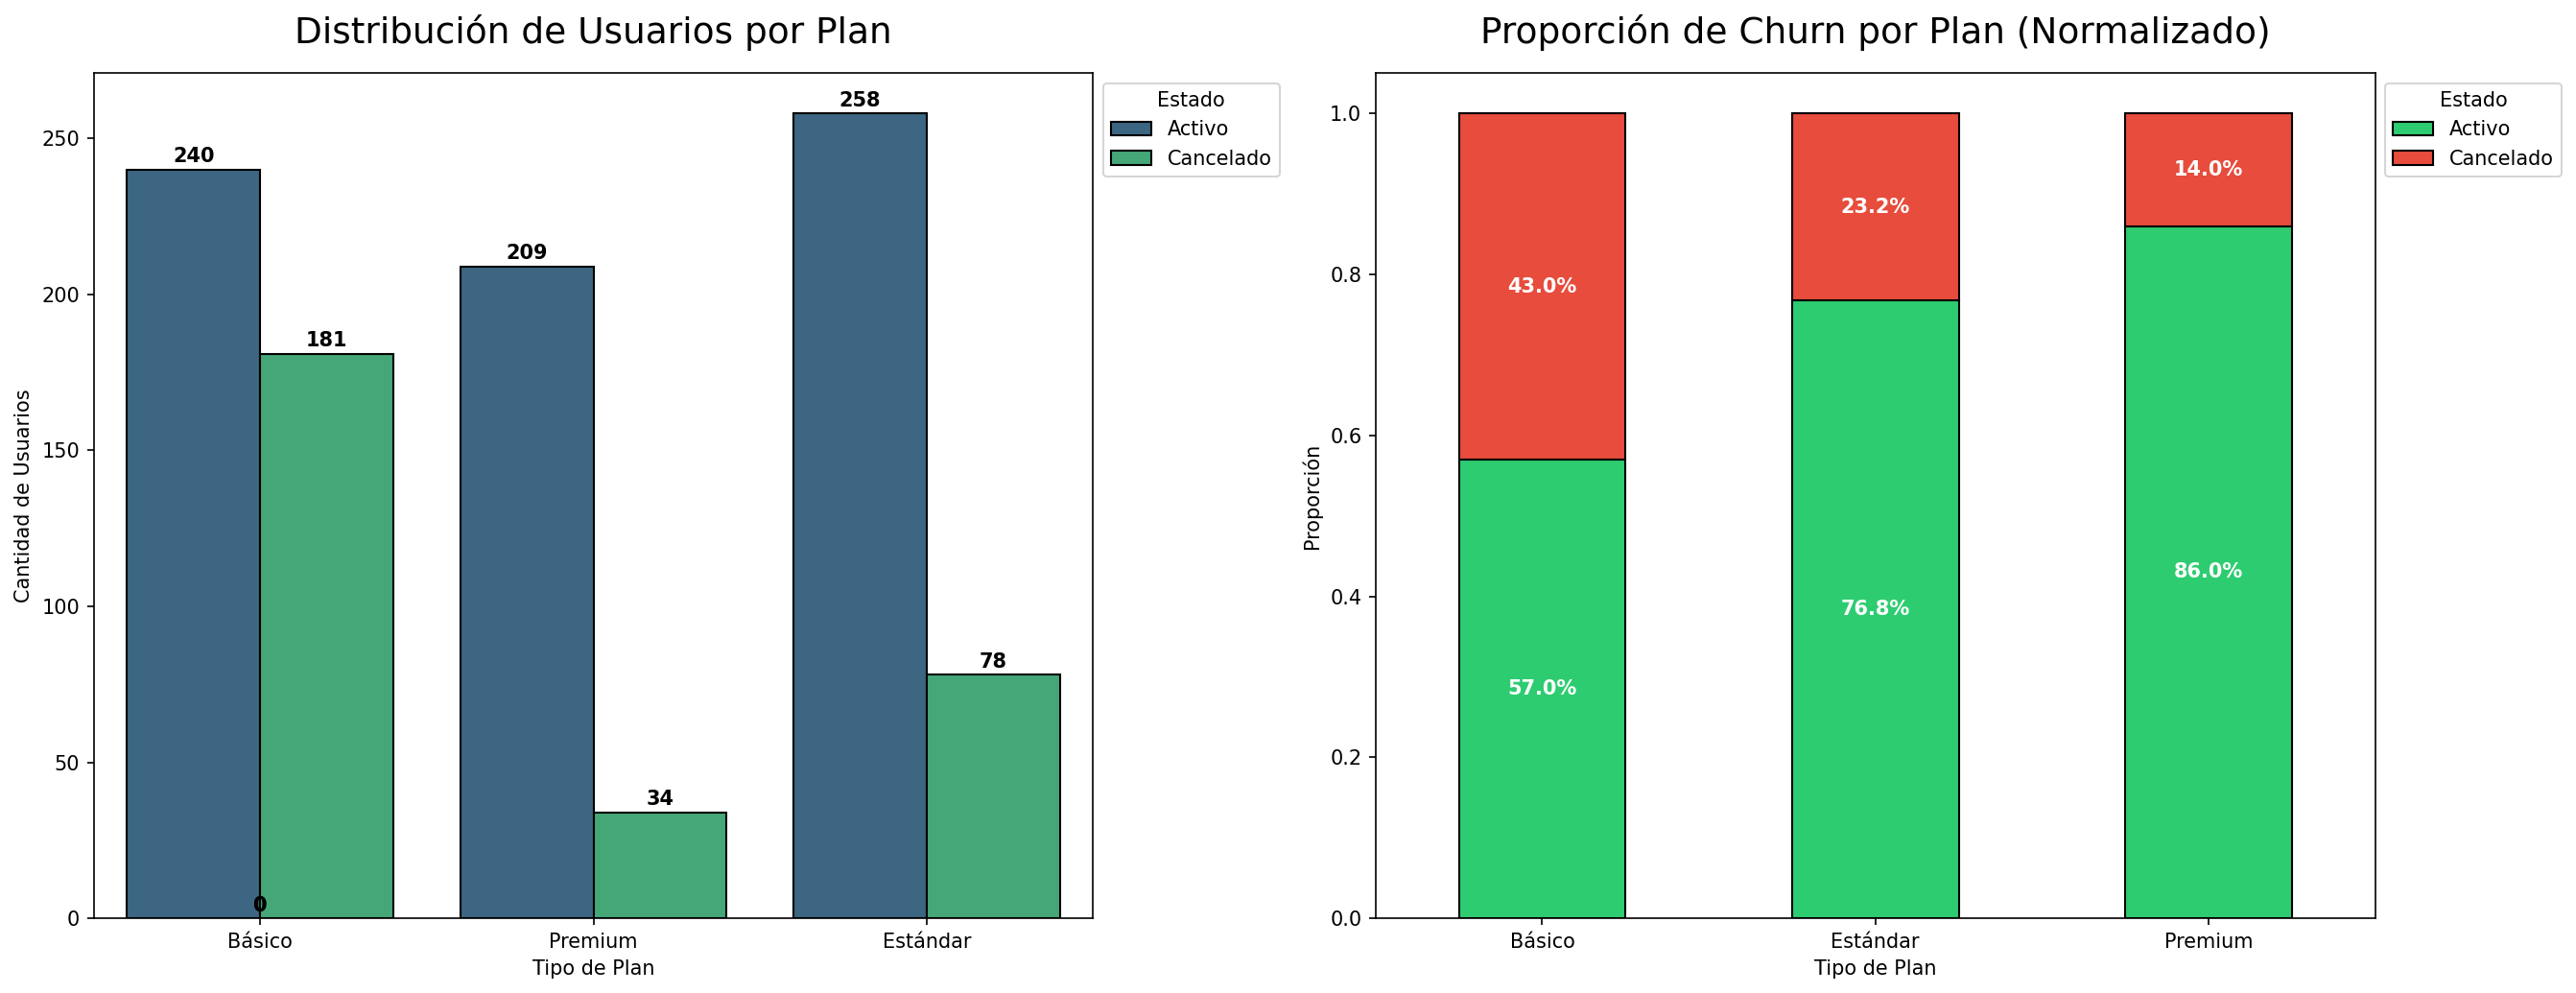

In [39]:
# Crear la figura con los subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi = 150)

# --- Gráfico 1: Distribución por Plan (Valores Absolutos) ---
sns.countplot(x='Plan', data=df, ax=axes[0], palette='viridis', hue='Estado', edgecolor = 'black')
axes[0].set_title('Distribución de Usuarios por Plan', fontsize=18, pad=15)
axes[0].set_xlabel('Tipo de Plan')
axes[0].set_ylabel('Cantidad de Usuarios')
axes[0].legend(title='Estado', loc='upper left', bbox_to_anchor=(1, 1))

# Agregar etiquetas al Gráfico 1
for bar in axes[0].patches:
    height = bar.get_height()
    axes[0].text(x = bar.get_x() + bar.get_width() / 2, 
                y = height + 1, # Un pequeño margen arriba
                s = f'{int(height)}', 
                ha = 'center', va = 'bottom', fontsize=10, fontweight='bold')

# --- Gráfico 2: Proporción de Churn (Barras Apiladas Normalizadas) ---
tabla_pct = pd.crosstab(df['Plan'], df['Estado'], normalize='index')
tabla_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#e74c3c'], rot=0, edgecolor = 'black')

axes[1].set_title('Proporción de Churn por Plan (Normalizado)', fontsize=18, pad=15)
axes[1].set_xlabel('Tipo de Plan')
axes[1].set_ylabel('Proporción')
axes[1].legend(title='Estado', loc='upper left', bbox_to_anchor=(1, 1))

# Agregar etiquetas al Gráfico 2 (Porcentajes)
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    axes[1].text(x + width/2, 
    y + height/2, # Colocar el texto en el centro de cada segmento
    f'{height:.1%}', 
    horizontalalignment='center', 
    verticalalignment='center',
    color='white', fontweight='bold')

# Ajuste para evitar que las leyendas externas se corten
plt.tight_layout()
plt.show()

In [33]:
chi2, p, dof, ex = chi2_contingency(tabla_contingencia)

print(f"\n--- Resultados de la Prueba Chi-cuadrado ---")
print(f"Estadístico Chi2: {chi2:.4f}")
print(f"P-valor: {p:.4e}")

if p < 0.05:
    print("Resultado: Significativo. Existe una relación entre el plan y la cancelación.")
else:
    print("Resultado: No significativo. No hay evidencia de relación.")


--- Resultados de la Prueba Chi-cuadrado ---
Estadístico Chi2: 71.6021
P-valor: 2.8301e-16
Resultado: Significativo. Existe una relación entre el plan y la cancelación.


In [41]:
df_exp = pd.DataFrame(ex, columns = tabla_contingencia.columns)
df_exp

Estado,Activo,Cancelado
0,297.647,123.353
1,237.552,98.448
2,171.801,71.199


In [34]:
df['Plan'].value_counts()

Plan
Básico      421
Estándar    336
Premium     243
Name: count, dtype: int64